# Taller: Resolución Numérica del Sistema Masa-Resorte
## Hecho por: Samuel Acuña y Carolina García

Este cuaderno resuelve el movimiento de un sistema acoplado masa-resorte, descrito por la ecuación diferencial ordinaria de segundo orden:

$$
m\frac{d^2x}{dt^2} + c\frac{dx}{dt} + kx = 0
$$

### Parámetros del sistema
- **Masa ($m$):** 20 kg
- **Constante del resorte ($k$):** 20 N/m
- **Coeficiente de amortiguamiento ($c$):** 5 (subamortiguado), 40 (amortiguamiento crítico) y 200 (sobreamortiguado)
- **Condiciones iniciales:** desplazamiento inicial $x = 1\,\text{m}$ y velocidad inicial cero
- **Periodo de simulación:** $0 < t < 15$ s

### Método Numérico: Runge-Kutta de quinto orden (Butcher)
Para obtener resultados más exactos y reducir el error relativo porcentual, se recomienda implementar el método de Butcher de quinto orden.

Este algoritmo aproxima el siguiente valor de la solución explorando el comportamiento de la función mediante seis iteraciones de pendientes ($k_1$ a $k_6$):

$$
y_{i+1} = y_i + \frac{1}{90}(7k_1 + 32k_3 + 12k_4 + 32k_5 + 7k_6)h
$$

In [ ]:
# Importa NumPy para trabajar con arreglos y operaciones vectorizadas en la simulación
import numpy as np

# Importa Matplotlib para generar la gráfica del desplazamiento en función del tiempo
import matplotlib.pyplot as plt

### 1. Configuración de Parámetros
Definimos las constantes físicas, los tres casos de amortiguamiento y un vector de tiempo discreto con un paso $h=0.2$ segundos.

In [ ]:
# Masa del sistema en kilogramos
m = 20.0

# Constante del resorte en N/m
k = 20.0

# Tres valores distintos de amortiguamiento para comparar cómo cambia la respuesta
c_values = [5, 40, 200]

# Etiquetas que se muestran en la gráfica para identificar cada caso
etiquetas = ['Subamortiguado (c=5)', 'Crítico (c=40)', 'Sobreamortiguado (c=200)']

# Tamaño del paso temporal de la simulación, en segundos
h = 0.2

# Vector de tiempo desde 0 hasta 15 segundos con incrementos de 0.2 s
t = np.arange(0, 15 + h, h)

# Número total de puntos de simulación
n_steps = len(t)

### 2. Implementación del Algoritmo y Graficación
Dado que tenemos una ecuación de segundo orden, la transformamos en un sistema de dos ecuaciones de primer orden: estado $x$ (posición) y estado $v$ (velocidad). Luego, aplicamos el ciclo iterativo calculando iterativamente las pendientes $k_1$ a $k_6$.

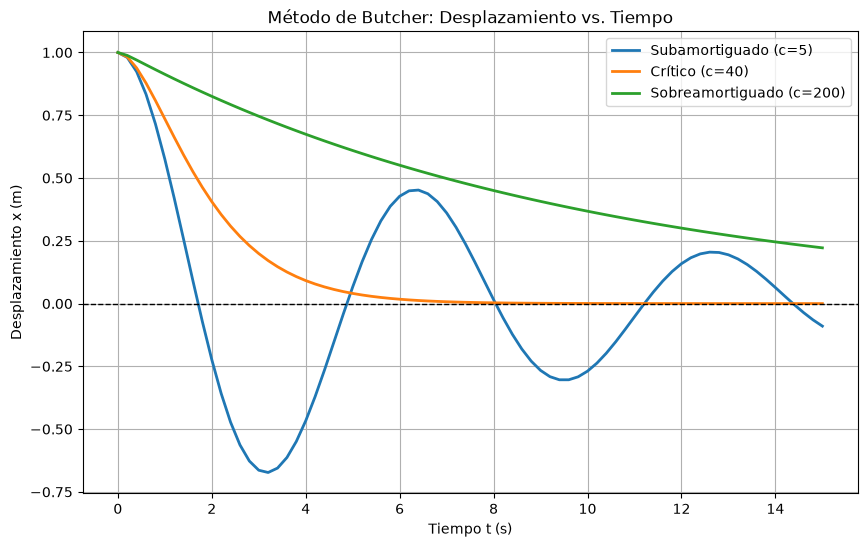

In [ ]:
# Crea una figura nueva con un tamaño adecuado para la visualización
plt.figure(figsize=(10, 6))

# Recorre cada valor de amortiguamiento para comparar la respuesta del sistema
for c, label in zip(c_values, etiquetas):
    # Guarda la posición y la velocidad en cada instante del tiempo
    # Fila 0: posición x, fila 1: velocidad v
    Y = np.zeros((2, n_steps))

    # Condiciones iniciales: x(0) = 1 m y v(0) = 0 m/s
    Y[:, 0] = [1.0, 0.0]

    # Define el sistema de ecuaciones de primer orden:
    # dx/dt = v
    # dv/dt = -(c/m)*v - (k/m)*x
    def f(t_val, Y_vec):
        x, v = Y_vec
        return np.array([v, -(c/m)*v - (k/m)*x])

    # Aplica el método de Runge-Kutta de quinto orden (Butcher) para avanzar en el tiempo
    for i in range(n_steps - 1):
        t_i = t[i]
        y_i = Y[:, i]

        # Calcula las seis pendientes del método RK-5
        k1 = f(t_i, y_i)
        k2 = f(t_i + h/4, y_i + h * (k1/4))
        k3 = f(t_i + h/4, y_i + h * (k1/8 + k2/8))
        k4 = f(t_i + h/2, y_i + h * (-k2/2 + k3))
        k5 = f(t_i + 3*h/4, y_i + h * (3*k1/16 + 9*k4/16))
        k6 = f(t_i + h, y_i + h * (-3*k1/7 + 2*k2/7 + 12*k3/7 - 12*k4/7 + 8*k5/7))

        # Actualiza la solución usando la fórmula de combinación ponderada de pendientes
        Y[:, i+1] = y_i + (h/90) * (7*k1 + 32*k3 + 12*k4 + 32*k5 + 7*k6)

    # Grafica solo la posición x(t) para cada caso de amortiguamiento
    plt.plot(t, Y[0, :], label=label, linewidth=2)

# Configura el título y los ejes para interpretar la gráfica final
plt.title('Método de Butcher: Desplazamiento vs. Tiempo')
plt.xlabel('Tiempo t (s)')
plt.ylabel('Desplazamiento x (m)')

# Dibuja la línea de referencia en el equilibrio x = 0
plt.axhline(0, color='black', linewidth=1, linestyle='--')

# Activa la cuadrícula y muestra la leyenda con cada caso
plt.grid(True)
plt.legend()

# Muestra la gráfica final
plt.show()